<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/AIChampion/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
1. Intelligent Pricing & Discount Optimization
2. Recommends dynamic pricing based on customer segments, historical data, and market competition.
3. Suggests optimal discount levels to maximize margins without losing deals.

# Strategy Followed
┌──────────────────────┐    ┌───────────────────┐    ┌──────────────────────────┐    ┌────────────────────┐    ┌───────────────────┐
│   Synthetic Data     │    │  Data Prep Layer  │    │  ML Modeling Layer       │    │ Optimization Layer │    │  Results / UI     │
│ (customers, prices,  │--->│  - clean data     │--->│ 1) Price Elasticity      │--->│ Max profit / deal  │--->│ Print tables,     │
│  discounts, sales)   │    │  - feature engine │    │ 2) Deal Conversion Model │    │ Suggest price      │    │ graphs, insights  │
└──────────────────────┘    └───────────────────┘    └──────────────────────────┘    └────────────────────┘    └───────────────────┘

                   

In [ ]:
!pip install xgboost
!pip install bayesian-optimization

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from xgboost import XGBClassifier
from bayes_opt import BayesianOptimization

In [ ]:
# note : change the path to your local system
# data = pd.read_csv('pricing_optimization_synthetic_data.csv')
GITHUB_RAW_URL_FOR_FILE = "https://raw.githubusercontent.com/rahilkhan-acadmic/APAIML-GradedMiniProject/refs/heads/develop/AIChampion/pricing_optimization_synthetic_data.csv"
data = pd.read_csv(GITHUB_RAW_URL_FOR_FILE)

In [ ]:
data

,customer_id,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%
0,1,Mid-Market,16766.73,4295.60,5,Low Competition,0.35,18134.40,-8.16
1,2,SMB,3935.22,23641.78,18,Moderate Competition,0.27,798.22,79.72
2,3,SMB,5717.46,14027.11,10,Moderate Competition,0.82,4836.93,15.40
3,4,Mid-Market,22666.75,21800.27,6,Moderate Competition,0.25,21663.38,4.43
4,5,Enterprise,15947.87,9545.20,1,High Competition,0.87,18088.41,-13.42
...,...,...,...,...,...,...,...,...,...
195,196,Mid-Market,23407.42,13269.87,15,High Competition,0.76,26145.24,-11.70
196,197,SMB,21743.49,17954.90,15,Moderate Competition,0.35,21659.47,0.39
197,198,SMB,11866.86,5970.14,1,High Competition,0.91,13724.45,-15.65
198,199,SMB,19270.03,6453.39,7,High Competition,0.97,23003.91,-19.38


In [ ]:
print(f'data.shape : {data.shape}')
print(f'\n\n-------------- data.describe() -------------- \n{data.describe()}')
print(f'\n\n-------------- data.info() --------------  ')
data.info()

data.shape : (200, 9)


-------------- data.describe() -------------- 
       customer_id  historical_price  competitor_price  \
count   200.000000        200.000000        200.000000   
mean    100.500000      13600.628200      14400.281450   
std      57.879185       6739.027476       7436.872946   
min       1.000000       2116.420000       2062.270000   
25%      50.750000       8013.635000       7983.587500   
50%     100.500000      14457.720000      14514.670000   
75%     150.250000      19070.585000      21428.980000   
max     200.000000      24781.620000      25993.170000   

       purchase_frequency_last_6m  demand_score  recommended_price  \
count                  200.000000    200.000000         200.000000   
mean                     9.610000      0.610100       13819.267750   
std                      5.470607      0.244655        8204.185966   
min                      1.000000      0.200000       -1263.030000   
25%                      5.000000      0.407500        6

## Step 3. Feature Engineering
### Alternative: Ordinal Encoding for Categorical Features

Ordinal encoding assigns a unique integer to each category. This can be suitable when there's an inherent order in your categories, or if your model (like tree-based models) can interpret these numerical representations without assuming an artificial order.

In [ ]:
data_ordinal = data.copy()

# Drop the 'customer_id' column
data_ordinal.drop(columns=['customer_id'], axis=1, inplace=True)

# Apply Ordinal Encoding to 'customer_segment' and 'market_condition'
ordinal_encoder = OrdinalEncoder()
data_ordinal[['customer_segment', 'market_condition']] = ordinal_encoder.fit_transform(data_ordinal[['customer_segment', 'market_condition']])

# Display the head of the new DataFrame with ordinal encoded columns
display(data_ordinal.head())

,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%
0,1.0,16766.73,4295.60,5,1.0,0.35,18134.40,-8.16
1,2.0,3935.22,23641.78,18,2.0,0.27,798.22,79.72
2,2.0,5717.46,14027.11,10,2.0,0.82,4836.93,15.40
3,1.0,22666.75,21800.27,6,2.0,0.25,21663.38,4.43
4,0.0,15947.87,9545.20,1,0.0,0.87,18088.41,-13.42


### Subtask:
Create a binary target variable 'deal_converted' in the `data_ordinal` DataFrame, setting it to 1 if `optimal_discount_%` is positive and 0 otherwise.

In [ ]:
data_ordinal['deal_converted'] = (data_ordinal['optimal_discount_%'] > 0).astype(int)
display(data_ordinal.head())

,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%,deal_converted
0,1.0,16766.73,4295.60,5,1.0,0.35,18134.40,-8.16,0
1,2.0,3935.22,23641.78,18,2.0,0.27,798.22,79.72,1
2,2.0,5717.46,14027.11,10,2.0,0.82,4836.93,15.40,1
3,1.0,22666.75,21800.27,6,2.0,0.25,21663.38,4.43,1
4,0.0,15947.87,9545.20,1,0.0,0.87,18088.41,-13.42,0


## Build Price Elasticity Model

### Subtask:
Implement a Log-linear regression model to predict price elasticity using `demand_score` as the target variable and `historical_price` as a key feature, along with other relevant features from `data_ordinal`.

**Reasoning:** This subtask requires implementing a Log-linear regression model. The first step is to define the features (X) and target (y) from the `data_ordinal` DataFrame as specified, apply logarithmic transformations to `historical_price` and `demand_score`, and then split the data into training and testing sets, before initializing and training a Linear Regression model.

In [ ]:
X = data_ordinal[['historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition']]
y = data_ordinal[['demand_score']]


# Log operation is applied to achieve following objective
# 1. Linearizing Relationships:
#     Relationship b/w price & demand is non-linear(e.g. exponential or multiplicative).
#     Apply logarithm -> transform - non-linear relationship ->linear
# 2. Model Specification:
#     In a log-log model where both price and demand are log-transformed, the model's coefficient for price directly reveals
#     how much demand changes percentage-wise for each one percent change in price, which is known as price elasticity.
# 3. Normalizing Skewed Data:
#     Price data -> distribution like data. Logarithmic transformations -> make distribution - symmetric & close -normal distribution.
#     Improve performance and validity of linear regression models.
X_elasticity = X.copy()
X_elasticity['historical_price'] = np.log(X_elasticity['historical_price'])
y_elasticity = np.log(y)

print(f'X_elasticity: \n{X_elasticity}')
print(f'y_elasticity: \n{y_elasticity}')

X_train_elasticity, X_test_elasticity, y_train_elasticity, y_test_elasticity = train_test_split(X_elasticity, y_elasticity, test_size=0.3, random_state=101)
log_linear_model = LinearRegression()
log_linear_model.fit(X_train_elasticity, y_train_elasticity)

print("Log-linear regression model trained successfully.")

X_elasticity: 
     historical_price  competitor_price  purchase_frequency_last_6m  \
0            9.727152           4295.60                           5   
1            8.277722          23641.78                          18   
2            8.651280          14027.11                          10   
3           10.028654          21800.27                           6   
4            9.677081           9545.20                           1   
..                ...               ...                         ...   
195         10.060808          13269.87                          15   
196          9.987070          17954.90                          15   
197          9.381505           5970.14                           1   
198          9.866306           6453.39                           7   
199          9.870680           2789.02                           4   

     customer_segment  market_condition  
0                 1.0               1.0  
1                 2.0               2.0  
2     

## Evaluate Models and Visualize Results

### Subtask:
Evaluation of performance of the Log-linear regression model using following metrics:
1. Mean Squared Error (MSE)
2. Mean Absolute Error (MBE)
3. R-squared score (R2)

In [ ]:
#1. Predict the demand score for the test set
y_pred_elasticity = log_linear_model.predict(X_test_elasticity)

#2. Calculate MSE
mse_elasticity = mean_squared_error(y_test_elasticity, y_pred_elasticity)

#3. Calculate MAE
mae_elasticity = mean_absolute_error(y_test_elasticity, y_pred_elasticity)

#4. Calculate R2 score
r2_elasticity = r2_score(y_test_elasticity, y_pred_elasticity)

print(f"Log-linear regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_elasticity:.4f}")
print(f"Mean Absolute Error (MAE): {mae_elasticity:.4f}")
print(f"R-squared (R2) Score: {r2_elasticity:.4f}")

Log-linear regression Model Performance:
Mean Squared Error (MSE): 0.2270
Mean Absolute Error (MAE): 0.4162
R-squared (R2) Score: -0.0044


## Build Deal Conversion Model

### Subtask:
Develop an XGBoost Classifier to predict deal conversion.
The model will use the engineered features from the data preparation step and the newly created binary target variable `deal_converted`.

**Reasoning**:
To develop the XGBoost Classifier, I will first define the feature matrix `X_conversion` and the target variable `y_conversion` as specified.
Then, I will split the data into training and testing sets using `train_test_split`.
Finally, I will initialize and train the `XGBClassifier` model.



In [ ]:
# 1. Define the feature matrix X_conversion and target variable y_conversion
X_conversion = data_ordinal[['historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition']]
y_conversion = data_ordinal['deal_converted']

#2. Split the data into training and test sets
X_train_conversion, X_test_conversion, y_train_conversion, y_test_conversion = train_test_split(X_conversion, y_conversion, test_size=0.3, random_state=101)

#3. Initialize an XGBClassifier model
xgb_model = XGBClassifier(eval_metric='logloss', random_state=101)

#4. Train the XGBClassifier model
xgb_model.fit(X_train_conversion, y_train_conversion)

print("XGBoost Classifier trained successfully")

XGBoost Classifier trained successfully


## Evaluate Models and Visualize Results

### Subtask:
Evaluate the performance of the XGBoost Classifier model using appropriate metrics.

**Reasoning**:
To evaluate the XGBoost Classifier, I will first predict probabilities and class labels for the test set. Then, I will calculate and print the accuracy score, ROC AUC score, and a classification report.



In [ ]:
# 1. Predict the deal_converted probabilities for the test set
y_pred_proba_conversion = xgb_model.predict_proba(X_test_conversion)[:, 1]

# 2. Predict the deal_converted labels for the test set
y_pred_conversion = xgb_model.predict(X_test_conversion)

# 3. Calculate the Accuracy Score
accuracy_conversion = accuracy_score(y_test_conversion, y_pred_conversion)

# 4. Calculate the Area Under the Receiver Operating Characteristic Curve (ROC AUC Score)
roc_auc_conversion = roc_auc_score(y_test_conversion, y_pred_proba_conversion)

# 5. Generate a classification report
classification_rep_conversion = classification_report(y_test_conversion, y_pred_conversion)

# 6. Print all the calculated metrics
print(f"XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_conversion:.4f}")
print(f"ROC AUC Score: {roc_auc_conversion:.4f}")
print(f"Classification Report:\n{classification_rep_conversion}")

XGBoost Classifier Model Performance:
Accuracy: 0.8167
ROC AUC Score: 0.9051
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        32
           1       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



**Precision:** Proportion of positive predictions that are actually correct:
*   `Precision = TP/(TP +FP)`
    
**Recal/Sensitivity:** Proportion of actual positive predictions that are correctly identified
*   `Recal = TP/(TP+FN)`

**F1-Score:** Harmonic Mean of `Precision` and `Recal`
*   `Recal = 2*(Precision * Recal)/(Precision + Recal)`

**Support:** No. of actual occurances of each class in the dataset. It provides context for other metrics but does not directly measures model performance.

**Accuracy:** Proportion of all predictions(both +ve and -ve) that are correct.
*Caveat: Misleading for imbalanced dataset. A model predicting only the majority class achieves high accuracy but fails to identify the minority class.*
*   `Accuracy = (TP + TN)/Total Predictions`        

    
    

## Implement Pricing Optimization

### Subtask:
Set up a framework for pricing optimization using Bayesian Optimization. This step will involve defining an objective function that leverages the predictions from both the Price Elasticity and Deal Conversion models to find optimal pricing strategies.


In [ ]:
#1. Caluclate the median values for relevant features from data_ordinal
median_competitor_price = data_ordinal['competitor_price'].median()
median_purchase_frequency = data_ordinal['purchase_frequency_last_6m'].median()
median_customer_segment = data_ordinal['customer_segment'].median()
median_market_condition = data_ordinal['market_condition'].median()

#2. Define the objective _fn() for Bayesian optimization
def objective_function(price_val):
    if price_val <= 0:
        return -np.inf #This ensure +ve value is returned

    # Prepare fts for the log_linear_model(price elasticity model)
    # X_elasticity has columns: 'historic_price', 'competitor_price', 'purchase_frequenc_last_6m','customer_segment', 'market_condition'
    features_elasticity = pd.DataFrame({
        'historical_price': [np.log(price_val)],
        'competitor_price': [median_competitor_price],
        'purchase_frequency_last_6m': [median_purchase_frequency],
        'customer_segment': [median_customer_segment],
        'market_condition': [median_market_condition]
    })

    # Ensure column order matches the training data for the model
    features_elasticity = features_elasticity[X_elasticity.columns]

    # Predict log_demand_score and then exponentiate to get predicted demand score
    # Corrected to ensure log_demand_score is a scalar
    log_demand_score = log_linear_model.predict(features_elasticity)[0][0]
    predicted_demand_score = np.exp(log_demand_score)

    # Prepare features for the xgb_model (deal conversion model)
    # X_conversion has columns: 'historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition'
    features_conversion = pd.DataFrame({
        'historical_price': [price_val],
        'competitor_price': [median_competitor_price],
        'purchase_frequency_last_6m': [median_purchase_frequency],
        'customer_segment': [median_customer_segment],
        'market_condition': [median_market_condition]
    })

    # Ensure column order matches the training data for the model
    features_conversion = features_conversion[X_conversion.columns]

    # Predict conversion_probability
    conversion_probability = xgb_model.predict_proba(features_conversion)[:, 1][0]

    # Calculate expected revenue
    expected_revenue = price_val * predicted_demand_score * conversion_probability
    return expected_revenue

# 4. Define the bounds for price_val
price_bounds = {
    'price_val': (data_ordinal['historical_price'].min(), data_ordinal['historical_price'].max())
}

# 5. Initialize BayesianOptimization
optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=price_bounds,
    random_state=101,
)

# 6. Run the Bayesian Optimization
optimizer.maximize(
    init_points=20,  # Number of steps of random exploration
    n_iter=50,       # Number of steps of Bayesian optimization
)

# Print the best parameters and the corresponding maximum value
print("\nOptimal Pricing Strategy:")
print(f"Best expected revenue: {optimizer.max['target']:.2f}")
print(f"Optimal price: {optimizer.max['params']['price_val']:.2f}")

|   iter    |  target   | price_val |
-------------------------------------
| 1         | 4323.3681 | 13820.698 |
| 2         | 791.03511 | 15050.714 |
| 3         | 1249.8747 | 2761.7940 |
| 4         | 2936.1404 | 6003.9926 |
| 5         | 472.48278 | 17648.359 |
| 6         | 392.34061 | 21016.859 |
| 7         | 4618.0226 | 9073.8707 |
| 8         | 578.47659 | 22370.339 |
| 9         | 1329.5901 | 18470.355 |
| 10        | 3143.5729 | 6421.4243 |
| 11        | 769.21552 | 14678.099 |
| 12        | 5203.0067 | 10097.561 |
| 13        | 3044.1205 | 6239.0476 |
| 14        | 1434.5812 | 19922.241 |
| 15        | 449.36290 | 23999.290 |
| 16        | 3673.0358 | 7382.7622 |
| 17        | 1895.0109 | 4010.3566 |
| 18        | 834.86197 | 15795.965 |
| 19        | 1343.1575 | 18639.186 |
| 20        | 4224.3425 | 8377.4282 |
| 21        | 3625.0829 | 12515.539 |
| 22        | 4981.9619 | 10954.808 |
| 23        | 4135.8735 | 13282.286 |
| 24        | 5139.7752 | 11572.905 |
| 25        


## Visualize Results and Feature Importance

### Subtask:
Visualize key findings, feature importances, and the outcomes of the pricing optimization to derive actionable insights.

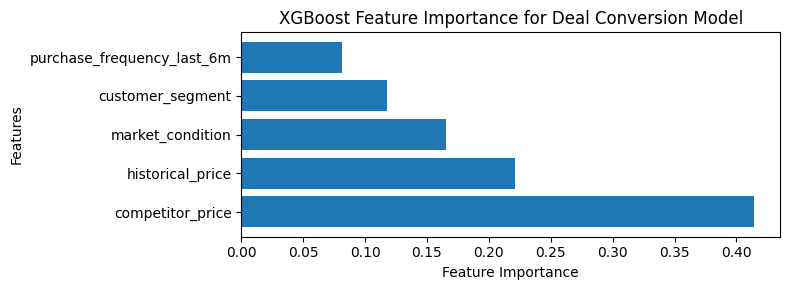

In [ ]:
import matplotlib.pyplot as plt

# Extract feature importances from the XGBoost model
feature_importances = xgb_model.feature_importances_
feature_names = X_conversion.columns

# Create a DataFrame for easier plotting
d = pd.DataFrame({'Feat_name': feature_names, 'Feat_imp': feature_importances})

# Sort by importance for better visualization
d = d.sort_values(by='Feat_imp', ascending=True)

# 1. Visualize the feature importances for the XGBoost model
plt.figure(figsize=(8, 3))
plt.barh(d['Feat_name'], d['Feat_imp'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance for Deal Conversion Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

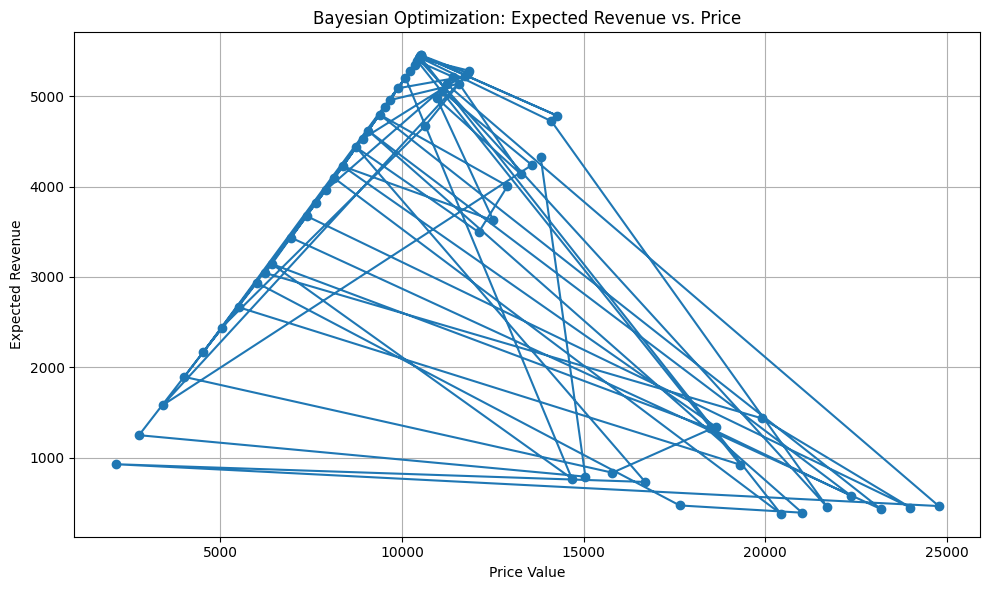

In [ ]:
#2. Extract the results from the optimizer
optimization_results = pd.DataFrame(optimizer.res)

#3. Plot the expected revenue against the explored price_val values
plt.figure(figsize=(10,6))
plt.plot(optimization_results['params'].apply(lambda x: x['price_val']), optimization_results['target'], marker='o', linestyle='-')
plt.xlabel('Price Value')
plt.ylabel('Expected Revenue')
plt.title('Bayesian Optimization: Expected Revenue vs. Price')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Updated approach:
def objective_function(price_val):
    if price_val <= 0:
        return -np.inf

    # DEBUG: Print the price being tested
    print(f"\nTesting price: ${price_val:.2f}")

    # Prepare features for elasticity model
    features_elasticity = pd.DataFrame({
        'historical_price': [np.log(price_val)],
        'competitor_price': [median_competitor_price],
        'purchase_frequency_last_6m': [median_purchase_frequency],
        'customer_segment': [median_customer_segment],
        'market_condition': [median_market_condition]
    })
    features_elasticity = features_elasticity[X_elasticity.columns]

    # Get demand prediction
    log_demand_score = log_linear_model.predict(features_elasticity)[0][0]
    predicted_demand_score = np.exp(log_demand_score)

    # DEBUG: Show demand prediction
    print(f"Log demand score: {log_demand_score:.4f}")
    print(f"Predicted demand score: {predicted_demand_score:.4f}")

    # Prepare features for conversion model
    features_conversion = pd.DataFrame({
        'historical_price': [price_val],
        'competitor_price': [median_competitor_price],
        'purchase_frequency_last_6m': [median_purchase_frequency],
        'customer_segment': [median_customer_segment],
        'market_condition': [median_market_condition]
    })
    features_conversion = features_conversion[X_conversion.columns]

    # Get conversion probability
    conversion_probability = xgb_model.predict_proba(features_conversion)[:, 1][0]

    # DEBUG: Show conversion probability
    print(f"Conversion probability: {conversion_probability:.4f}")

    # Calculate expected revenue
    expected_revenue = price_val * predicted_demand_score * conversion_probability

    # DEBUG: Show calculation
    print(f"Expected revenue: ${price_val:.2f} × {predicted_demand_score:.4f} × {conversion_probability:.4f} = ${expected_revenue:.2f}")

    return expected_revenue

# 4. Define the bounds for price_val
price_bounds = {
    'price_val': (data_ordinal['historical_price'].min(), data_ordinal['historical_price'].max())
}

# 5. Initialize BayesianOptimization
optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=price_bounds,
    random_state=101,
)

# 6. Run the Bayesian Optimization
optimizer.maximize(
    init_points=20,  # Number of steps of random exploration
    n_iter=50,       # Number of steps of Bayesian optimization
)

# Print the best parameters and the corresponding maximum value
print("\nOptimal Pricing Strategy:")
print(f"Best expected revenue: {optimizer.max['target']:.2f}")
print(f"Optimal price: {optimizer.max['params']['price_val']:.2f}")

|   iter    |  target   | price_val |
-------------------------------------

Testing price: $13820.70
Log demand score: -0.5944
Predicted demand score: 0.5519
Conversion probability: 0.5668
Expected revenue: $13820.70 × 0.5519 × 0.5668 = $4323.37
| 1         | 4323.3681 | 13820.698 |

Testing price: $15050.71
Log demand score: -0.5845
Predicted demand score: 0.5574
Conversion probability: 0.0943
Expected revenue: $15050.71 × 0.5574 × 0.0943 = $791.04
| 2         | 791.03511 | 15050.714 |

Testing price: $2761.79
Log demand score: -0.7808
Predicted demand score: 0.4580
Conversion probability: 0.9880
Expected revenue: $2761.79 × 0.4580 × 0.9880 = $1249.87
| 3         | 1249.8747 | 2761.7940 |

Testing price: $6003.99
Log demand score: -0.6909
Predicted demand score: 0.5011
Conversion probability: 0.9759
Expected revenue: $6003.99 × 0.5011 × 0.9759 = $2936.14
| 4         | 2936.1404 | 6003.9926 |

Testing price: $17648.36
Log demand score: -0.5661
Predicted demand score: 0.5677
Conversion

In [ ]:

# Extract feature importances from the XGBoost model
feature_importances = xgb_model.feature_importances_
feature_names = X_conversion.columns

# Create a DataFrame for easier plotting
d = pd.DataFrame({'Feat_name': feature_names, 'Feat_imp': feature_importances})

# Sort by importance for better visualization
d = d.sort_values(by='Feat_imp', ascending=True)

# 1. Visualize the feature importances for the XGBoost model
plt.figure(figsize=(8, 3))
plt.barh(d['Feat_name'], d['Feat_imp'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance for Deal Conversion Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#2. Extract the results from the optimizer
optimization_results = pd.DataFrame(optimizer.res)

#3. Plot the expected revenue against the explored price_val values
plt.figure(figsize=(10,6))
plt.plot(optimization_results['params'].apply(lambda x: x['price_val']), optimization_results['target'], marker='o', linestyle='-')
plt.xlabel('Price Value')
plt.ylabel('Expected Revenue')
plt.title('Bayesian Optimization: Expected Revenue vs. Price')
plt.grid(True)
plt.tight_layout()
plt.show()